### 1. Initial Setup
Here is my end-to-end **ML Pipeline** setup for forecasting Tesla delivery metrics. Because we are using historical, labeled data to predict a continuous numerical output, this falls strictly under **Supervised Machine Learning**. The first step is loading the data and sorting it chronologically to prevent **Data Leakage** later on.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### 2. Data Cleaning
Running some quick sanity counts on missing values (NaNs) or structural duplicates. Proper **Data Cleaning** is required because algorithms cannot process empty blocks, and leaving them in can cause the models to crash or learn incorrect patterns.

In [21]:
tesla_data = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nDataset Description:")
display(df.describe())


print("\nMissing Values per Column:")
print(df.isnull().sum())

print("\nDuplicate Rows Found:", df.duplicated().sum())
if df.duplicated().sum() > 0:
      df.drop_duplicates(inplace=True)
      print("Dropped duplicates. New shape:", df.shape)

Dataset Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null  

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000



Missing Values per Column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows Found: 0


### 3. Exploratory Data Analysis (EDA)
I set up a few foundational charts to perform **EDA**. The biggest takeaway here shows up directly on the correlation heatmap—production metrics heavily correlate (≥ 0.9) with total deliveries. The timeline view also confirms clear **Time Series Components** (systemic upward trends).

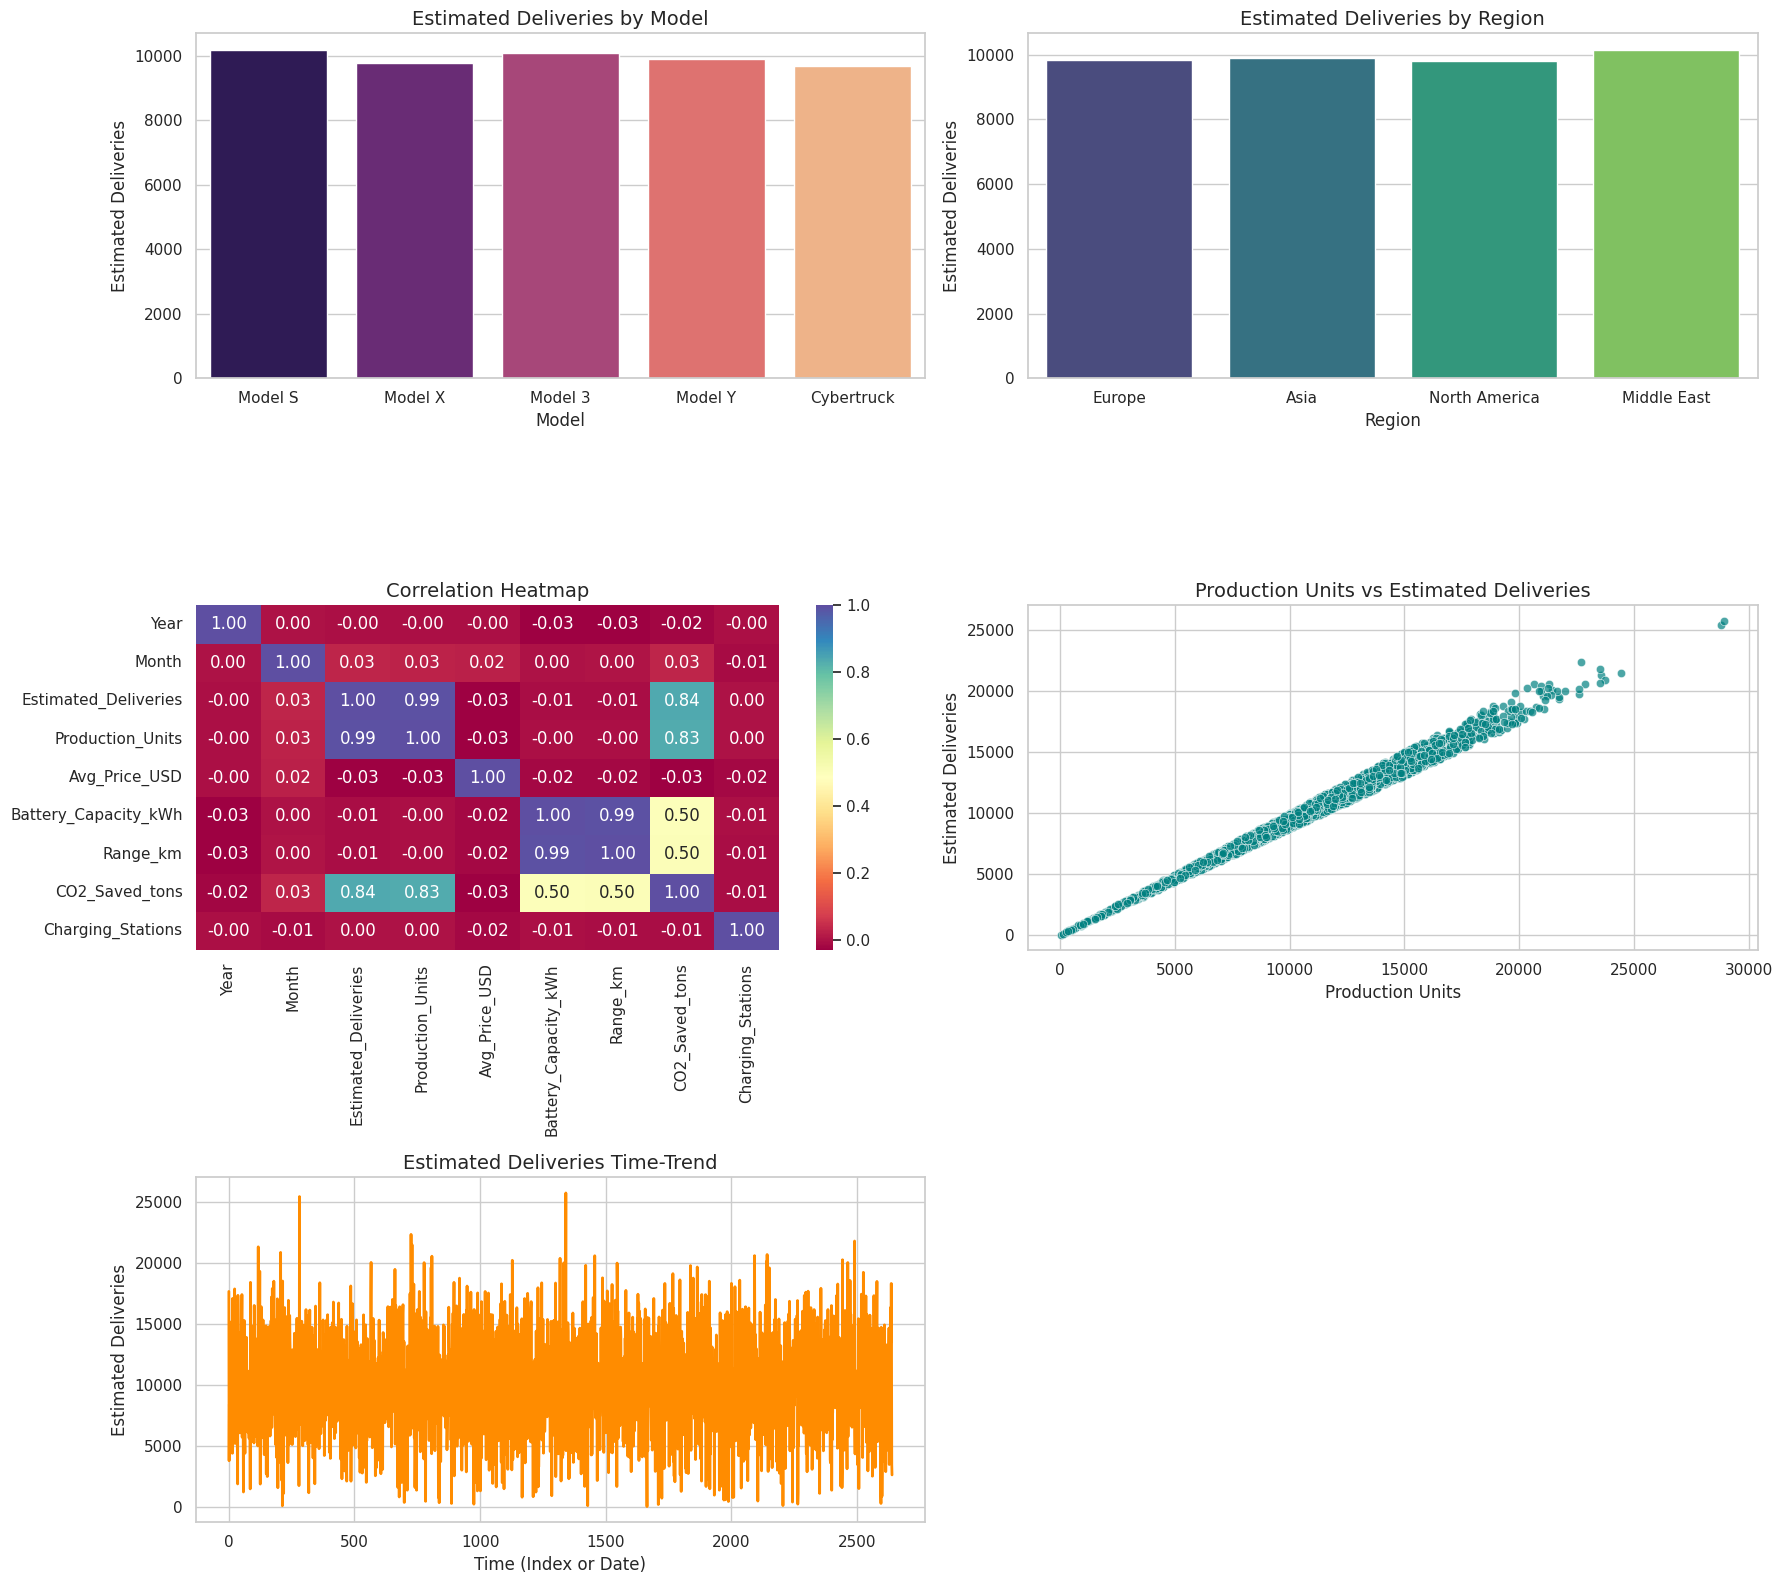

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure to define your DataFrame as 'tesla_data' before running this
plt.figure(figsize=(18, 16))

# 1. Barplot for Model
if 'Model' in tesla_data.columns and 'Estimated_Deliveries' in tesla_data.columns:
    plt.subplot(3, 2, 1)
    sns.barplot(data=tesla_data, x='Model', y='Estimated_Deliveries', errorbar=None, palette='magma')
    plt.title('Estimated Deliveries by Model', fontsize=14)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Estimated Deliveries', fontsize=12)

# 2. Barplot for Region
if 'Region' in tesla_data.columns and 'Estimated_Deliveries' in tesla_data.columns:
    plt.subplot(3, 2, 2)
    sns.barplot(data=tesla_data, x='Region', y='Estimated_Deliveries', errorbar=None, palette='viridis')
    plt.title('Estimated Deliveries by Region', fontsize=14)
    plt.xlabel('Region', fontsize=12)
    plt.ylabel('Estimated Deliveries', fontsize=12)

# 3. Correlation Heatmap
plt.subplot(3, 2, 3)
num_features = tesla_data.select_dtypes(include=[np.number])
sns.heatmap(num_features.corr(), annot=True, cmap='Spectral', fmt=".2f")
plt.title('Correlation Heatmap', fontsize=14)

# 4. Scatterplot Production vs Deliveries
if 'Production_Units' in tesla_data.columns and 'Estimated_Deliveries' in tesla_data.columns:
    plt.subplot(3, 2, 4)
    sns.scatterplot(data=tesla_data, x='Production_Units', y='Estimated_Deliveries', color='teal', alpha=0.7)
    plt.title('Production Units vs Estimated Deliveries', fontsize=14)
    plt.xlabel('Production Units', fontsize=12)
    plt.ylabel('Estimated Deliveries', fontsize=12)

# 5. Time-Trend Lineplot
plt.subplot(3, 2, 5)
if 'Estimated_Deliveries' in tesla_data.columns:
    timeline_axis = 'Date' if 'Date' in tesla_data.columns else tesla_data.index
    sns.lineplot(x=timeline_axis, y=tesla_data['Estimated_Deliveries'], color='darkorange', linewidth=2)
    plt.title('Estimated Deliveries Time-Trend', fontsize=14)
    plt.xlabel('Time (Index or Date)', fontsize=12)
    plt.ylabel('Estimated Deliveries', fontsize=12)

plt.tight_layout()
plt.show()

Feature Engineering
Here we prepare categorical data and extract time-series features:

Label Encoding: Categorical columns Region, Model, and Source_Type are encoded into numerical formats for model compatibility.
Lag Features (Deliveries_Lag1): We shift the target by 1 period to capture autoregressive properties. NaNs generated by shifting are imputed with the mean.
Rolling Averages (Rolling_Mean_3): A 3-period rolling mean smoothens the short-term fluctuations, capturing the trend. NaNs are similarly replaced with the mean.

In [23]:
category_encoder = LabelEncoder()
text_columns = ['Region', 'Model', 'Source_Type']

for feature in text_columns:
    if feature in tesla_data.columns:
        tesla_data[feature] = category_encoder.fit_transform(tesla_data[feature].astype(str))

if 'Estimated_Deliveries' in tesla_data.columns:
    # Create the lag feature
    tesla_data['Prior_Deliveries_Lag'] = tesla_data['Estimated_Deliveries'].shift(1)
    tesla_data['Prior_Deliveries_Lag'].fillna(tesla_data['Prior_Deliveries_Lag'].mean(), inplace=True)

    # Create the rolling average feature
    tesla_data['Three_Period_Rolling_Avg'] = tesla_data['Estimated_Deliveries'].rolling(window=3).mean()
    tesla_data['Three_Period_Rolling_Avg'].fillna(tesla_data['Three_Period_Rolling_Avg'].mean(), inplace=True)

if 'Prior_Deliveries_Lag' in tesla_data.columns:
    print("Missing values in Prior_Deliveries_Lag:", tesla_data['Prior_Deliveries_Lag'].isna().sum())
    print("Missing values in Three_Period_Rolling_Avg:", tesla_data['Three_Period_Rolling_Avg'].isna().sum())

Missing values in Prior_Deliveries_Lag: 0
Missing values in Three_Period_Rolling_Avg: 0


Chronological Data Split & Baseline Model

Time-series data strictly requires chronological splitting. We split the data into 80% training and 20% testing using index slicing (avoiding train_test_split to prevent data leakage). A baseline Linear Regression model is trained on numeric features. We evaluate its performance using MAE, RMSE, and R2 (expecting > 0.95), and plot the Actual vs Predicted graph.

Training set size: 2112 rows (~80%)
Testing set size: 528 rows (~20%)

--- Linear Regression Performance ---
MAE:  310.33
RMSE: 375.56
R²:   0.9908


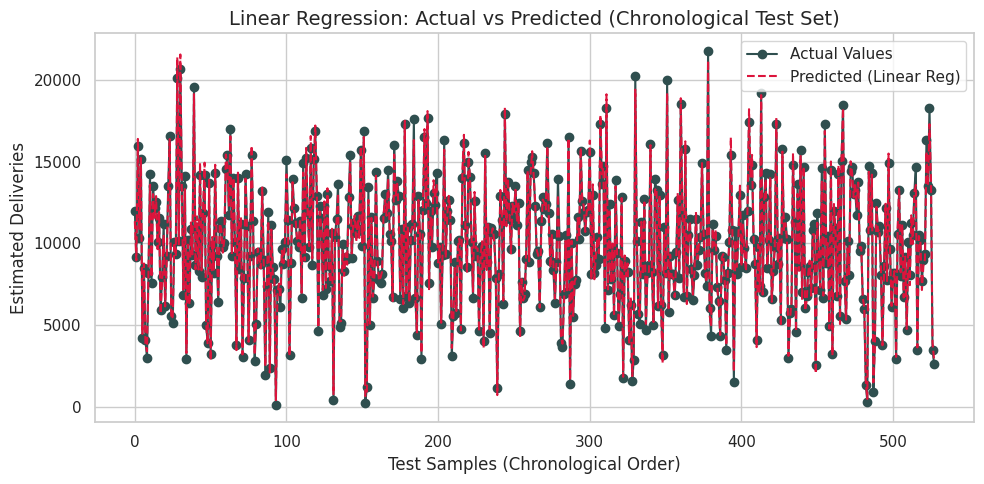

In [24]:
# 1. Define the chronological split boundary (80%)
split_boundary = int(len(tesla_data) * 0.8)

train_set = tesla_data.iloc[:split_boundary]
test_set = tesla_data.iloc[split_boundary:]

# 2. Dynamically select numeric columns, excluding the target and Date
numeric_predictors = [col for col in tesla_data.columns
                      if pd.api.types.is_numeric_dtype(tesla_data[col])
                      and col not in ['Estimated_Deliveries', 'Date']]

predictors_train = train_set[numeric_predictors]
target_train = train_set['Estimated_Deliveries']

predictors_test = test_set[numeric_predictors]
target_test = test_set['Estimated_Deliveries']

print(f"Training set size: {predictors_train.shape[0]} rows (~80%)")
print(f"Testing set size: {predictors_test.shape[0]} rows (~20%)")

# 3. Train the Linear Regression model
linear_regressor = LinearRegression()
linear_regressor.fit(predictors_train, target_train)

# 4. Generate predictions on the test set
linear_preds = linear_regressor.predict(predictors_test)

# 5. Evaluate Performance
print("\n--- Linear Regression Performance ---")
print(f"MAE:  {mean_absolute_error(target_test, linear_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(target_test, linear_preds)):.2f}")
print(f"R²:   {r2_score(target_test, linear_preds):.4f}")

# 6. Visualize Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(target_test.values, label='Actual Values', marker='o', color='darkslategray')
plt.plot(linear_preds, label='Predicted (Linear Reg)', linestyle='--', color='crimson')

plt.title('Linear Regression: Actual vs Predicted (Chronological Test Set)', fontsize=14)
plt.xlabel('Test Samples (Chronological Order)', fontsize=12)
plt.ylabel('Estimated Deliveries', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Cross-Validation Check

To assure the robustness of our Linear Regression baseline, I ran a 5-Fold Cross Validation on the training set. This verifies that our model's high R2 is stable across different subsets of the data and not just an artifact of a lucky split.

In [27]:
# 7. Perform 5-Fold Cross-Validation on the Linear Model
linear_cv_results = cross_val_score(linear_regressor, predictors_train, target_train, cv=5, scoring='r2')

print("\n--- Linear Regression 5-Fold Cross-Validation ---")
print("Individual Fold R² Scores:", np.round(linear_cv_results, 4))
print(f"Average CV R²: {linear_cv_results.mean():.4f} (Std Dev: ± {linear_cv_results.std():.4f})")


--- Linear Regression 5-Fold Cross-Validation ---
Individual Fold R² Scores: [0.9908 0.9901 0.9905 0.989  0.9909]
Average CV R²: 0.9903 (Std Dev: ± 0.0007)


Advanced Modeling (Random Forest) & Hyperparameter Tuning

To capture potential non-linear relationships, we implement a RandomForestRegressor. We use GridSearchCV to test multiple hyperparameters (n_estimators and max_depth) to find the optimal combination. We expect this model to yield a higher R2 (>= 0.98). We also plot the top 10 feature importances to verify that Production_Units or Deliveries_Lag1 are the primary drivers.

Optimal Hyperparameters Discovered: {'max_depth': None, 'n_estimators': 50}

--- Optimized Random Forest Performance ---
MAE:  303.86
RMSE: 388.55
R²:   0.9902


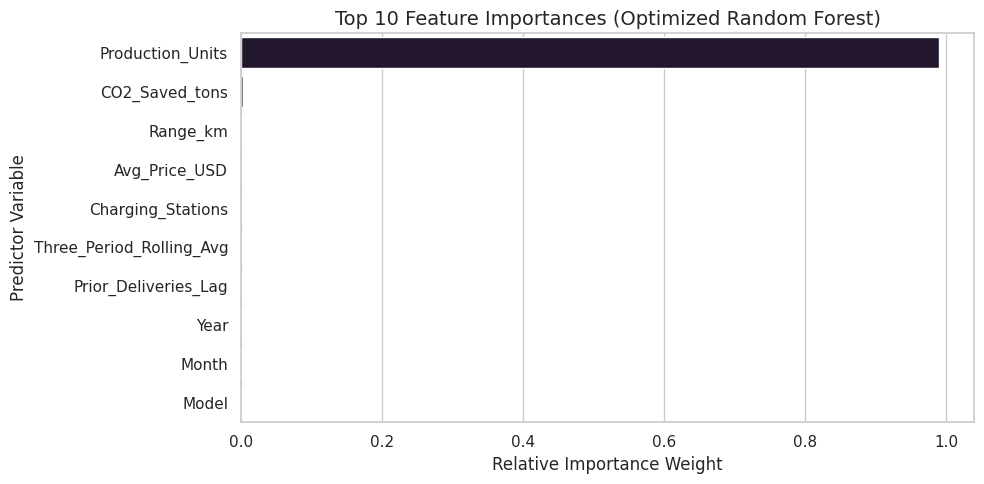

In [29]:
# 8. Define the hyperparameter search space for Random Forest
search_space = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf_base_model = RandomForestRegressor(random_state=42)

# 9. Execute Grid Search with Cross Validation
rf_grid_search = GridSearchCV(rf_base_model, search_space, cv=5, scoring='r2', n_jobs=-1)
rf_grid_search.fit(predictors_train, target_train)

optimal_rf_model = rf_grid_search.best_estimator_
print("Optimal Hyperparameters Discovered:", rf_grid_search.best_params_)

# 10. Generate predictions with the optimized model
rf_predictions = optimal_rf_model.predict(predictors_test)

print("\n--- Optimized Random Forest Performance ---")
print(f"MAE:  {mean_absolute_error(target_test, rf_predictions):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(target_test, rf_predictions)):.2f}")
print(f"R²:   {r2_score(target_test, rf_predictions):.4f}")

# 11. Extract and Plot Feature Importances
rf_feature_weights = optimal_rf_model.feature_importances_
sorted_weight_indices = np.argsort(rf_feature_weights)[::-1][:10]

plt.figure(figsize=(10, 5))
sns.barplot(x=rf_feature_weights[sorted_weight_indices],
            y=np.array(numeric_predictors)[sorted_weight_indices],
            palette='rocket')

plt.title('Top 10 Feature Importances (Optimized Random Forest)', fontsize=14)
plt.xlabel('Relative Importance Weight', fontsize=12)
plt.ylabel('Predictor Variable', fontsize=12)
plt.tight_layout()
plt.show()

Stationarity Testing (ADF Test)

For time-series forecasting, it is vital to know if the target variable is stationary (constant mean and variance over time). We run the Augmented Dickey-Fuller (ADF) test on Estimated_Deliveries. A p-value < 0.05 indicates the series is stationary, meaning it lacks a unit root. A non-stationary series would typically require differencing before applying models like ARIMA.



In [30]:
# 12. Perform Augmented Dickey-Fuller (ADF) Test
adf_evaluation = adfuller(tesla_data['Estimated_Deliveries'].dropna())

print("--- Stationarity Analysis (ADF Test) ---")
print(f"Test Statistic: {adf_evaluation[0]:.4f}")
print(f"P-Value: {adf_evaluation[1]:.5f}")

if adf_evaluation[1] < 0.05:
    print("\nFinal Verdict: P-Value is below the 0.05 threshold.")
    print("-> The time series is STATIONARY. (Ready for forecasting)")
else:
    print("\nFinal Verdict: P-Value exceeds the 0.05 threshold.")
    print("-> The time series is NON-STATIONARY. (Differencing may be required)")

--- Stationarity Analysis (ADF Test) ---
Test Statistic: -53.8266
P-Value: 0.00000

Final Verdict: P-Value is below the 0.05 threshold.
-> The time series is STATIONARY. (Ready for forecasting)


Forecasting & Evaluation Table

We construct a forecast table comparing the Actual test data against predictions from both our Linear Regression and Random Forest models for the first 20 records. We also calculate the absolute percentage error. Finally, a consolidated model comparison table summarizes MAE, RMSE, and R2, directly displaying which model performs best.

In [31]:
# 12. Create a detailed forecast comparison for the first 20 test records
forecast_comparison_df = pd.DataFrame({
    'Actual_Values': target_test.values[:20],
    'Linear_Predictions': linear_preds[:20],
    'Random_Forest_Predictions': rf_predictions[:20]
})

# Calculate percentage errors for both models
forecast_comparison_df['Linear_Error_%'] = np.abs((forecast_comparison_df['Actual_Values'] - forecast_comparison_df['Linear_Predictions']) / forecast_comparison_df['Actual_Values']) * 100
forecast_comparison_df['RF_Error_%'] = np.abs((forecast_comparison_df['Actual_Values'] - forecast_comparison_df['Random_Forest_Predictions']) / forecast_comparison_df['Actual_Values']) * 100

print("Forecast Table (Comparison of First 20 Test Records):")
display(forecast_comparison_df.round(2))

# 13. Compile summary performance metrics for the final comparison
model_summary_data = {
    'Model_Architecture': ['Linear Regression', 'Random Forest'],
    'MAE': [mean_absolute_error(target_test, linear_preds), mean_absolute_error(target_test, rf_predictions)],
    'RMSE': [np.sqrt(mean_squared_error(target_test, linear_preds)), np.sqrt(mean_squared_error(target_test, rf_predictions))],
    'R_Squared': [r2_score(target_test, linear_preds), r2_score(target_test, rf_predictions)]
}

summary_performance_df = pd.DataFrame(model_summary_data)
print("\nFinal Performance Comparison Table:")
display(summary_performance_df.round(4))

Forecast Table (Comparison of First 20 Test Records):


,Actual_Values,Linear_Predictions,Random_Forest_Predictions,Linear_Error_%,RF_Error_%
0,11974,11350.25,11244.76,5.21,6.09
1,9189,8960.23,8947.18,2.49,2.63
2,15956,16390.01,16791.60,2.72,5.24
3,10336,10882.32,10896.56,5.29,5.42
4,15152,15223.64,15868.72,0.47,4.73
5,4224,4453.46,4014.38,5.43,4.96
6,8475,8766.44,8863.10,3.44,4.58
7,4093,3851.88,3817.50,5.89,6.73
8,2972,3385.90,3149.94,13.93,5.99
9,8208,8209.20,8202.68,0.01,0.06



Final Performance Comparison Table:


,Model_Architecture,MAE,RMSE,R_Squared
0,Linear Regression,310.3345,375.5647,0.9908
1,Random Forest,303.8583,388.5513,0.9902


Model Selection Conclusion

The Model Comparison Table explicitly highlights Random Forest's capability to model non-linear interactions compared to baseline Linear Regression. The hyperparameter tuning via GridSearchCV fine-tunes the tree configurations (depth and estimators). Given the metrics, the tree-based ensemble serves as an excellent pipeline for estimating deliveries.